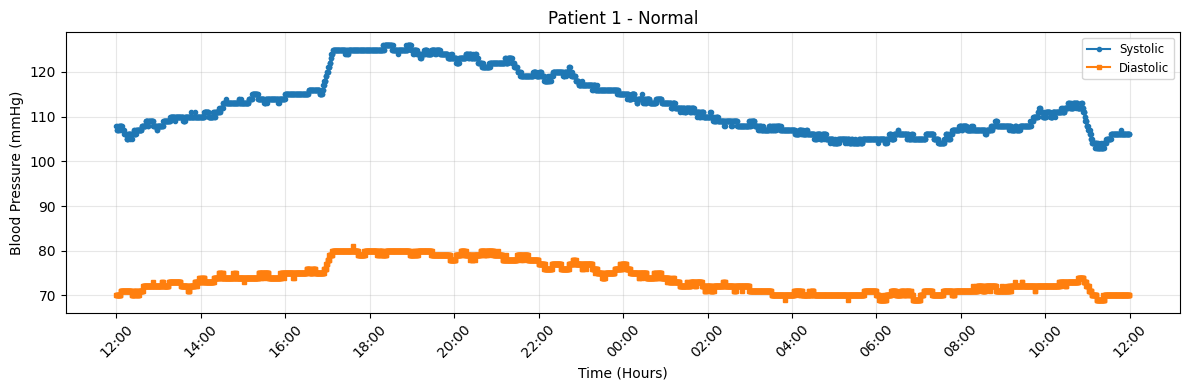

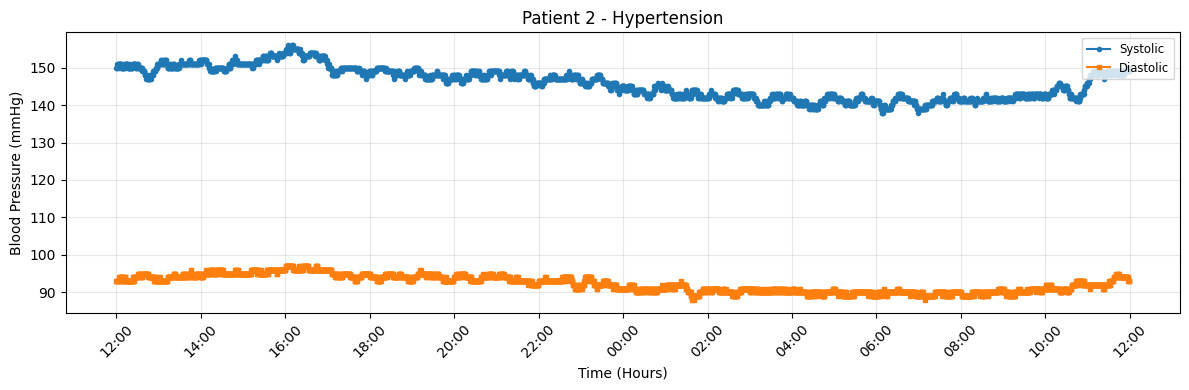

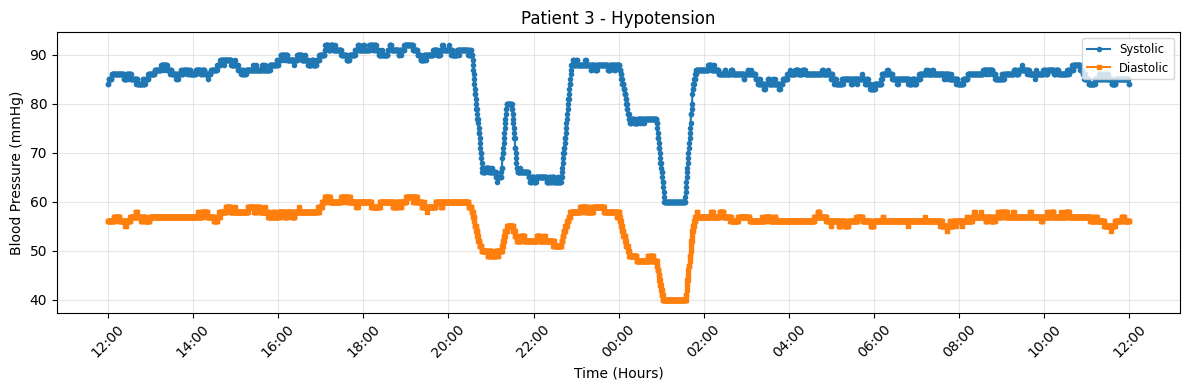

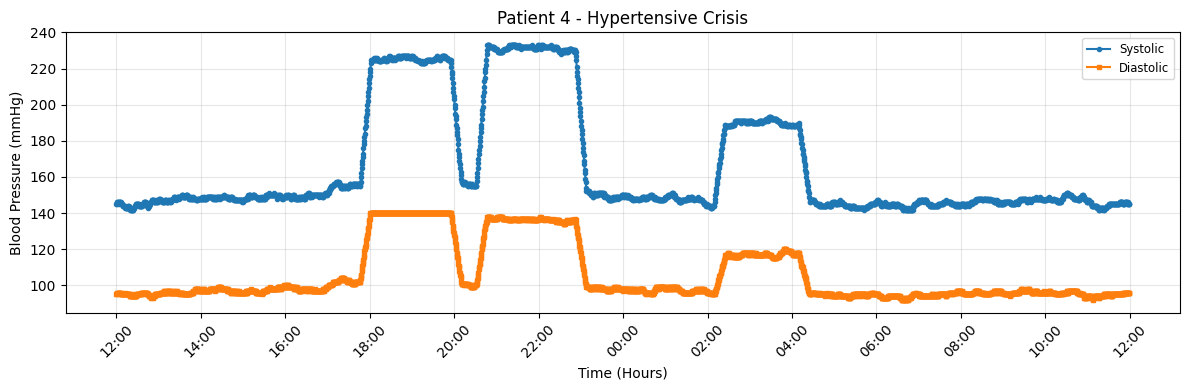

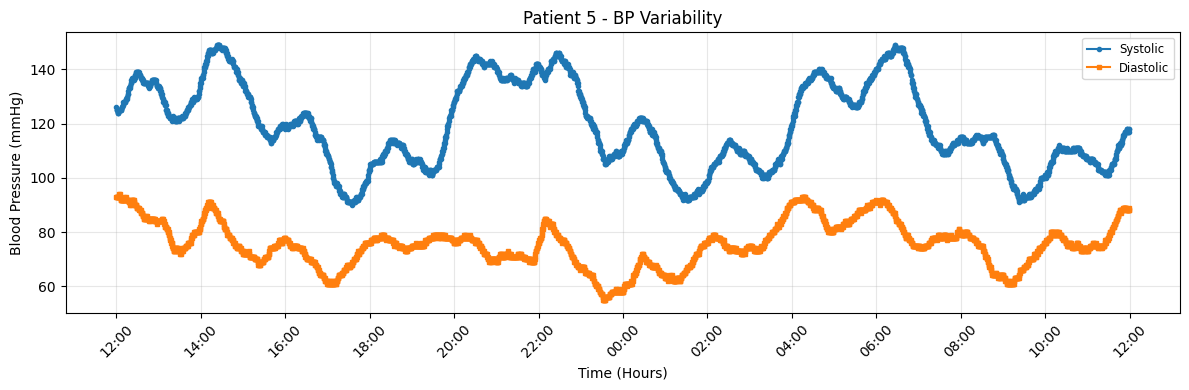

Saved CSV: blood_pressure_5patients_circadian_style.csv (5 patients, 2880 rows each)


In [14]:
# Re-run generation & plotting (kernel restarted previously)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

np.random.seed(12345)

# timestamps
start = datetime(2025, 9, 18, 12, 0, 0)
n = 24 * 60 * 60 // 30  # 2880
timestamps = [start + timedelta(seconds=30*i) for i in range(n)]
t = np.arange(n) / n  # normalized time for a day [0,1)

def circadian_baseline(t_array, amp=10):
    base = amp * np.sin(2*np.pi*t_array)
    hours = t_array * 24
    dip_mask = ((hours >= 23) | (hours < 5)).astype(float)
    base = base - dip_mask * (amp * 0.9)
    return base

def smooth(arr, win=21):
    return pd.Series(arr).rolling(win, center=True, min_periods=1).mean().to_numpy()

def gen_patient(pattern):
    base = circadian_baseline(t, amp=10)
    if pattern == "normal":
        sys = 115 + base + np.random.normal(0, 4, n)
        dia = 75 + base/2 + np.random.normal(0, 3, n)
    elif pattern == "hypertension":
        sys = 145 + base*0.4 + np.random.normal(0, 6, n)
        dia = 92 + base*0.25 + np.random.normal(0, 4, n)
        hours = (t * 24)
        sleep_mask = ((hours >= 23) | (hours < 5)).astype(float)
        sys += sleep_mask * 8
        dia += sleep_mask * 4
    elif pattern == "hypotension":
        sys = 88 + base*0.3 + np.random.normal(0, 4, n)
        dia = 58 + base*0.2 + np.random.normal(0, 3, n)
        for _ in range(4):
            start = np.random.randint(100, n-200)
            dur = np.random.randint(20, 200)
            sys[start:start+dur] -= np.random.uniform(10, 25)
            dia[start:start+dur] -= np.random.uniform(6, 12)
    elif pattern == "hypertensive_crisis":
        sys = 150 + base*0.6 + np.random.normal(0, 7, n)
        dia = 98 + base*0.35 + np.random.normal(0, 5, n)
        for _ in range(3):
            start = np.random.randint(200, n-400)
            dur = np.random.randint(60, 400)
            add_s = np.random.uniform(40, 80)
            add_d = np.random.uniform(20, 40)
            sys[start:start+dur] += add_s
            dia[start:start+dur] += add_d
        for _ in range(8):
            idx = np.random.randint(0, n)
            sys[idx] += np.random.uniform(10, 30)
    elif pattern == "bp_variability":
        sys = 120 + 20*np.sin(2*np.pi*3*t) + 10*np.sin(2*np.pi*12*t) + np.random.normal(0, 8, n)
        dia = 78 + 10*np.sin(2*np.pi*3*t + 0.8) + 6*np.sin(2*np.pi*12*t + 1.2) + np.random.normal(0, 6, n)
        for _ in range(5):
            start = np.random.randint(100, n-200)
            dur = np.random.randint(50, 300)
            sys[start:start+dur] += np.random.uniform(-25, 25)
            dia[start:start+dur] += np.random.uniform(-15, 15)
    else:
        raise ValueError("Unknown pattern")
    sys = smooth(sys, win=31)
    dia = smooth(dia, win=31)
    sys = np.clip(sys, 60, 240)
    dia = np.clip(dia, 40, 140)
    return sys, dia

patterns = ["normal", "hypertension", "hypotension", "hypertensive_crisis", "bp_variability"]
labels = ["Normal", "Hypertension", "Hypotension", "Hypertensive Crisis", "BP Variability"]

all_dfs = []
for pid, pat in enumerate(patterns, start=1):
    sys, dia = gen_patient(pat)
    dfp = pd.DataFrame({
        "patient_id": pid,
        "timestamp": timestamps,
        "systolic": np.round(sys).astype(int),
        "diastolic": np.round(dia).astype(int)
    })
    all_dfs.append(dfp)
    
    plt.figure(figsize=(12, 4))  # Tăng width để hiển thị tốt hơn
    plt.plot(dfp["timestamp"], dfp["systolic"], label="Systolic", marker='o', markersize=3)
    plt.plot(dfp["timestamp"], dfp["diastolic"], label="Diastolic", marker='s', markersize=3)
    plt.title(f"Patient {pid} - {labels[pid-1]}")
    plt.xlabel("Time (Hours)")
    plt.ylabel("Blood Pressure (mmHg)")
    plt.legend(loc="upper right", fontsize="small")
    
    # Định dạng trục x cho giờ
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
    plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.HourLocator(interval=2))  # Hiển thị mỗi 2 giờ
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

df_all = pd.concat(all_dfs).reset_index(drop=True)
df_all.to_csv("blood_pressure_5patients_circadian_style.csv", index=False)
print("Saved CSV: blood_pressure_5patients_circadian_style.csv (5 patients, 2880 rows each)")


In [15]:
import pandas as pd
import numpy as np

# Load dữ liệu
df = pd.read_csv("blood_pressure_5patients_circadian_style.csv", parse_dates=["timestamp"])

def compute_metrics(df_patient):
    sbp = df_patient["systolic"]
    dbp = df_patient["diastolic"]
    mean_sbp = sbp.mean()
    mean_dbp = dbp.mean()
    max_sbp = sbp.max()
    max_dbp = dbp.max()
    min_sbp = sbp.min()
    min_dbp = dbp.min()
    std_sbp = sbp.std()
    std_dbp = dbp.std()
    # compute night dipping: define night = 23:00-05:00
    df_patient["hour"] = df_patient["timestamp"].dt.hour + df_patient["timestamp"].dt.minute/60
    # mask for night
    night_mask = ((df_patient["hour"] >= 23) | (df_patient["hour"] < 5))
    day_mask = ~night_mask
    # average SBP day vs night
    day_sbp = df_patient.loc[day_mask, "systolic"]
    night_sbp = df_patient.loc[night_mask, "systolic"]
    mean_day_sbp = day_sbp.mean()
    mean_night_sbp = night_sbp.mean()
    if mean_day_sbp is None or mean_night_sbp is None:
        dipping_pct = np.nan
    else:
        dipping_pct = (mean_day_sbp - mean_night_sbp) / mean_day_sbp * 100
    return {
        "mean_sbp": mean_sbp,
        "mean_dbp": mean_dbp,
        "max_sbp": max_sbp,
        "max_dbp": max_dbp,
        "min_sbp": min_sbp,
        "min_dbp": min_dbp,
        "std_sbp": std_sbp,
        "std_dbp": std_dbp,
        "dipping_pct": dipping_pct
    }

def classify(metrics):
    # apply rules
    if metrics["max_sbp"] >= 180 or metrics["max_dbp"] >= 120:
        return "Hypertensive Crisis"
    if metrics["mean_sbp"] < 90 or metrics["mean_dbp"] < 60 or metrics["min_sbp"] < 80 or metrics["min_dbp"] < 50:
        return "Hypotension"
    if metrics["mean_sbp"] >= 140 or metrics["mean_dbp"] >= 90:
        return "Hypertension"
    # Option: elevated/stage1
    if (metrics["mean_sbp"] >= 120 and metrics["mean_sbp"] < 140) or (metrics["mean_dbp"] >= 80 and metrics["mean_dbp"] < 90):
        return "Elevated / Stage 1 Hypertension"
    # High variability
    if metrics["std_sbp"] >= 20 or (metrics["max_sbp"] - metrics["min_sbp"]) >= 50:
        return "BP Variability"
    # Normal
    return "Normal"

# Process each patient
results = []
for pid in df["patient_id"].unique():
    dpf = df[df["patient_id"] == pid].copy()
    m = compute_metrics(dpf)
    cls = classify(m)
    print(f"Patient {pid}: metrics = {m}")
    print(f" → Classified as: {cls}")
    results.append((pid, cls))

# Output results


Patient 1: metrics = {'mean_sbp': np.float64(112.78854166666666), 'mean_dbp': np.float64(73.87013888888889), 'max_sbp': np.int64(126), 'max_dbp': np.int64(81), 'min_sbp': np.int64(103), 'min_dbp': np.int64(69), 'std_sbp': np.float64(6.704869114453989), 'std_dbp': np.float64(3.3971481380995554), 'dipping_pct': np.float64(2.4765339131357043)}
 → Classified as: Normal
Patient 2: metrics = {'mean_sbp': np.float64(145.91458333333333), 'mean_dbp': np.float64(92.3392361111111), 'max_sbp': np.int64(156), 'max_dbp': np.int64(97), 'min_sbp': np.int64(138), 'min_dbp': np.int64(88), 'std_sbp': np.float64(4.11846912665421), 'std_dbp': np.float64(2.232692012480163), 'dipping_pct': np.float64(2.680726878494301)}
 → Classified as: Hypertension
Patient 3: metrics = {'mean_sbp': np.float64(84.19583333333334), 'mean_dbp': np.float64(56.074305555555554), 'max_sbp': np.int64(92), 'max_dbp': np.int64(61), 'min_sbp': np.int64(60), 'min_dbp': np.int64(40), 'std_sbp': np.float64(7.319758478867626), 'std_dbp': 

In [2]:
# =====================================================
# PATIENT 6: Kịch bản 7 ngày - Treatment Response Scenario
# Ngày 1: Huyết áp cao (Stage 2 Hypertension)
# Ngày 2-7: Huyết áp bình thường với spike ngắn (do hoạt động)
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

np.random.seed(42)  # For reproducibility

# Generate 7 days of data (every 30 seconds)
start_date = datetime(2025, 9, 18, 12, 0, 0)
n_per_day = 24 * 60 * 60 // 30  # 2880 readings per day
n_total = n_per_day * 7  # 7 days
timestamps = [start_date + timedelta(seconds=30*i) for i in range(n_total)]

def circadian_pattern(t_array, amp=8):
    """Circadian rhythm: higher during day, lower at night"""
    base = amp * np.sin(2 * np.pi * t_array - np.pi/2)  # Peak around midday
    hours = t_array * 24
    # Night dip (23:00 - 05:00)
    night_mask = ((hours >= 23) | (hours < 5)).astype(float)
    base = base - night_mask * (amp * 0.5)
    return base

def generate_activity_spikes(n, num_spikes=3, duration_range=(30, 120)):
    """Generate short-duration BP spikes (physical activity)"""
    spike_mask = np.zeros(n)
    spike_times = []
    
    for _ in range(num_spikes):
        # Random time (avoid night hours)
        hour = np.random.choice([8, 9, 10, 14, 15, 16, 18, 19, 20])
        idx = int((hour / 24) * n)
        duration = np.random.randint(*duration_range)  # 15-60 minutes worth of readings
        
        if idx + duration < n:
            # Gradual rise and fall
            rise = np.linspace(0, 1, duration // 3)
            peak = np.ones(duration // 3)
            fall = np.linspace(1, 0, duration - 2 * (duration // 3))
            spike_profile = np.concatenate([rise, peak, fall])
            spike_mask[idx:idx+duration] = spike_profile
            spike_times.append((idx, duration))
    
    return spike_mask, spike_times

def generate_patient6_7days():
    """Generate 7-day BP data for Patient 6"""
    all_sys = []
    all_dia = []
    
    for day in range(7):
        # Normalized time for this day [0, 1)
        t = np.arange(n_per_day) / n_per_day
        circadian = circadian_pattern(t, amp=8)
        
        if day == 0:
            # DAY 1: High blood pressure (Stage 2 Hypertension)
            # SBP: 145-165, DBP: 90-100
            sys_base = 155 + circadian * 0.6 + np.random.normal(0, 5, n_per_day)
            dia_base = 95 + circadian * 0.3 + np.random.normal(0, 3, n_per_day)
            
            # Add some variability
            sys_base += np.random.normal(0, 3, n_per_day)
            dia_base += np.random.normal(0, 2, n_per_day)
            
        else:
            # DAY 2-7: Normal blood pressure (with activity spikes)
            # SBP: 110-125, DBP: 70-80
            sys_base = 118 + circadian * 0.8 + np.random.normal(0, 3, n_per_day)
            dia_base = 75 + circadian * 0.4 + np.random.normal(0, 2, n_per_day)
            
            # Add activity spikes (2-4 per day)
            num_spikes = np.random.randint(2, 5)
            spike_mask, spike_times = generate_activity_spikes(n_per_day, num_spikes=num_spikes)
            
            # Spikes increase BP by 15-25 mmHg systolic, 8-12 mmHg diastolic
            spike_intensity_sys = np.random.uniform(15, 25)
            spike_intensity_dia = np.random.uniform(8, 12)
            
            sys_base += spike_mask * spike_intensity_sys
            dia_base += spike_mask * spike_intensity_dia
            
            print(f"Day {day+1}: Generated {num_spikes} activity spikes at times:", 
                  [(start_date + timedelta(days=day, seconds=30*idx)).strftime("%H:%M") for idx, dur in spike_times])
        
        # Smooth to make realistic
        sys_smooth = pd.Series(sys_base).rolling(21, center=True, min_periods=1).mean().to_numpy()
        dia_smooth = pd.Series(dia_base).rolling(21, center=True, min_periods=1).mean().to_numpy()
        
        # Clip to realistic ranges
        sys_smooth = np.clip(sys_smooth, 80, 190)
        dia_smooth = np.clip(dia_smooth, 50, 110)
        
        all_sys.extend(sys_smooth)
        all_dia.extend(dia_smooth)
    
    # Create DataFrame
    df_patient6 = pd.DataFrame({
        "patient_id": 6,
        "timestamp": timestamps,
        "systolic": np.round(all_sys).astype(int),
        "diastolic": np.round(all_dia).astype(int)
    })
    
    return df_patient6

# Generate data
df_patient6 = generate_patient6_7days()

# Display summary statistics by day
print("\n" + "="*60)
print("PATIENT 6 - 7 DAY TREATMENT RESPONSE SCENARIO")
print("="*60)
for day in range(7):
    day_start = start_date + timedelta(days=day)
    day_end = day_start + timedelta(days=1)
    df_day = df_patient6[(df_patient6['timestamp'] >= day_start) & (df_patient6['timestamp'] < day_end)]
    
    print(f"\nDay {day+1} ({day_start.strftime('%Y-%m-%d')}):")
    print(f"  Systolic:  Mean={df_day['systolic'].mean():.1f}, Range=[{df_day['systolic'].min()}-{df_day['systolic'].max()}]")
    print(f"  Diastolic: Mean={df_day['diastolic'].mean():.1f}, Range=[{df_day['diastolic'].min()}-{df_day['diastolic'].max()}]")
    
    # Count elevated readings
    elevated = ((df_day['systolic'] >= 140) | (df_day['diastolic'] >= 90)).sum()
    print(f"  Elevated readings: {elevated} / {len(df_day)} ({elevated/len(df_day)*100:.1f}%)")

print("\n" + "="*60)
print(f"Total records: {len(df_patient6)}")
print("="*60)


Day 2: Generated 2 activity spikes at times: ['21:00', '20:00']
Day 3: Generated 2 activity spikes at times: ['20:00', '06:00']
Day 4: Generated 2 activity spikes at times: ['22:00', '03:00']
Day 5: Generated 3 activity spikes at times: ['20:00', '08:00', '08:00']
Day 6: Generated 4 activity spikes at times: ['02:00', '08:00', '03:00', '22:00']
Day 7: Generated 4 activity spikes at times: ['08:00', '02:00', '03:00', '03:00']

PATIENT 6 - 7 DAY TREATMENT RESPONSE SCENARIO

Day 1 (2025-09-18):
  Systolic:  Mean=154.5, Range=[145-164]
  Diastolic: Mean=94.6, Range=[89-99]
  Elevated readings: 2880 / 2880 (100.0%)

Day 2 (2025-09-19):
  Systolic:  Mean=118.3, Range=[107-145]
  Diastolic: Mean=75.2, Range=[69-89]
  Elevated readings: 91 / 2880 (3.2%)

Day 3 (2025-09-20):
  Systolic:  Mean=118.0, Range=[107-144]
  Diastolic: Mean=74.9, Range=[69-86]
  Elevated readings: 43 / 2880 (1.5%)

Day 4 (2025-09-21):
  Systolic:  Mean=117.9, Range=[107-145]
  Diastolic: Mean=74.9, Range=[69-89]
  Elev

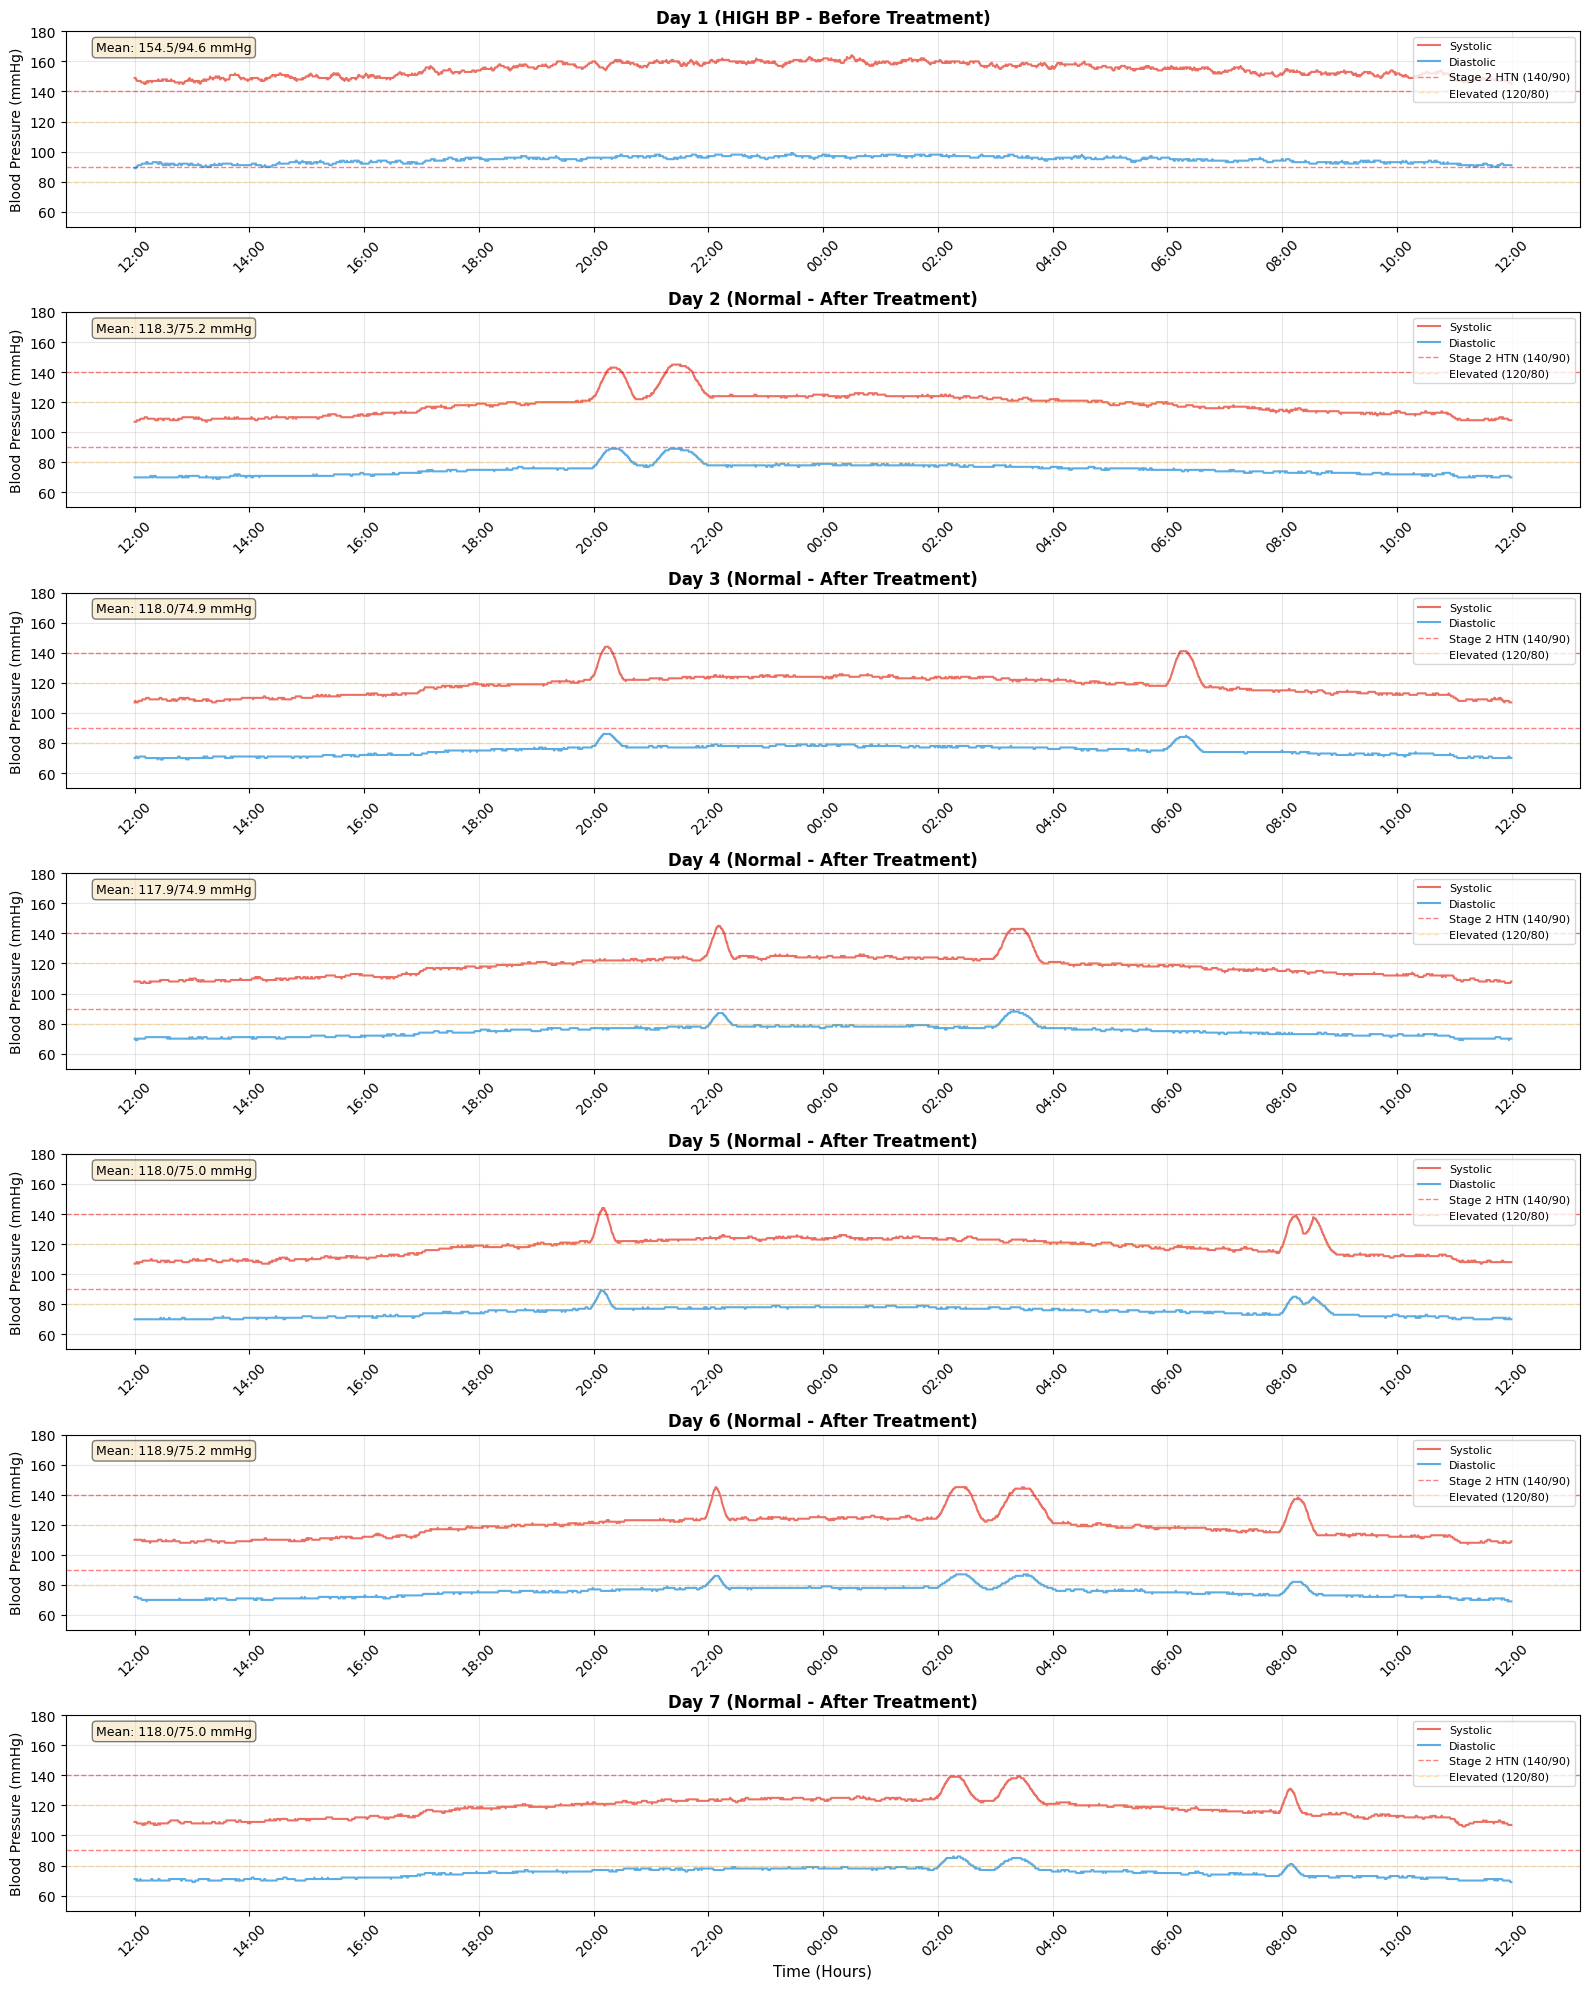


✅ Visualization saved as 'patient6_7day_bp_monitoring.png'


In [8]:
# =====================================================
# VISUALIZATION: Plot 7-day data for Patient 6
# =====================================================

fig, axes = plt.subplots(7, 1, figsize=(16, 20))

for day in range(7):
    day_start = start_date + timedelta(days=day)
    day_end = day_start + timedelta(days=1)
    df_day = df_patient6[(df_patient6['timestamp'] >= day_start) & (df_patient6['timestamp'] < day_end)]
    
    ax = axes[day]
    
    # Plot systolic and diastolic
    ax.plot(df_day['timestamp'], df_day['systolic'], color='#e74c3c', label='Systolic', linewidth=1.5, alpha=0.8)
    ax.plot(df_day['timestamp'], df_day['diastolic'], color='#3498db', label='Diastolic', linewidth=1.5, alpha=0.8)
    
    # Add threshold lines
    ax.axhline(y=140, color='red', linestyle='--', alpha=0.5, linewidth=1, label='Stage 2 HTN (140/90)')
    ax.axhline(y=90, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.axhline(y=120, color='orange', linestyle='--', alpha=0.3, linewidth=1, label='Elevated (120/80)')
    ax.axhline(y=80, color='orange', linestyle='--', alpha=0.3, linewidth=1)
    
    # Formatting
    day_label = "Day 1 (HIGH BP - Before Treatment)" if day == 0 else f"Day {day+1} (Normal - After Treatment)"
    ax.set_title(day_label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Blood Pressure (mmHg)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)
    
    # Format x-axis
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.HourLocator(interval=2))
    ax.tick_params(axis='x', rotation=45)
    
    # Set y-axis limits
    ax.set_ylim(50, 180)
    
    # Add statistics text box
    stats_text = f"Mean: {df_day['systolic'].mean():.1f}/{df_day['diastolic'].mean():.1f} mmHg"
    ax.text(0.02, 0.95, stats_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.xlabel('Time (Hours)', fontsize=11)
plt.tight_layout()
plt.savefig('patient6_7day_bp_monitoring.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved as 'patient6_7day_bp_monitoring.png'")


In [7]:
# =====================================================
# SAVE DATA: Append Patient 6 to existing CSV or create new file
# =====================================================

# Option 1: Save separately for Patient 6
df_patient6.to_csv("blood_pressure_patient6_7days.csv", index=False)
print("✅ Saved: blood_pressure_patient6_7days.csv")
print(f"   Total records: {len(df_patient6)} (7 days × 2880 readings/day)")

# Display final summary
print("\n" + "="*70)
print("SUMMARY: Patient 6 Data Generation Complete")
print("="*70)
print(f"Scenario: Treatment Response Monitoring (7 days)")
print(f"- Day 1: Stage 2 Hypertension (Mean ~155/95 mmHg)")
print(f"- Days 2-7: Normal BP with activity spikes (Mean ~118/75 mmHg)")
print(f"- Total readings: {len(df_patient6):,}")
print(f"- Sampling rate: Every 30 seconds")
print("="*70)


✅ Saved: blood_pressure_patient6_7days.csv
   Total records: 20160 (7 days × 2880 readings/day)

SUMMARY: Patient 6 Data Generation Complete
Scenario: Treatment Response Monitoring (7 days)
- Day 1: Stage 2 Hypertension (Mean ~155/95 mmHg)
- Days 2-7: Normal BP with activity spikes (Mean ~118/75 mmHg)
- Total readings: 20,160
- Sampling rate: Every 30 seconds
